# **ANÁLISIS DE DATOS EXPLORATORIO**

Para saber con qué tipo de datos estoy trabajando, qué puedo mostrar en el dashboard y cuál es la información que realmente me ayudará a tomar mejores decisiones financieras al momento de invertir, primero haré un análisis exploratorio sobre los datos que da Yahoo Finance y las acciones de las diferentes empresas y su impacto global.

In [6]:
# Importamos librerías necesarias
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Los tickers son símbolos bursátiles. Es el código corto que identifica a una acción en la bolsa de valores.
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'NVDA']

data = yf.download(tickers=tickers, period="2y", auto_adjust=True, progress=False)
#Obtenemos los precios de cierre para poder graficarlos
prices = data["Close"]
prices.tail() # Mostramos los últimos 5 registros de cada ticker

Ticker,AAPL,AMZN,GOOG,META,MSFT,NVDA
Date,,,,,,
2026-06-01,306.309998,261.260010,372.579987,600.469971,460.519989,224.098816
2026-06-02,315.200012,256.519989,358.390015,597.630005,441.309998,222.560608
2026-06-03,310.260010,250.020004,355.679993,622.979980,427.339996,214.500000
2026-06-04,311.230011,253.789993,369.269989,627.570007,428.049988,218.660004
2026-06-05,307.339996,246.029999,365.760010,593.000000,416.670013,205.100006


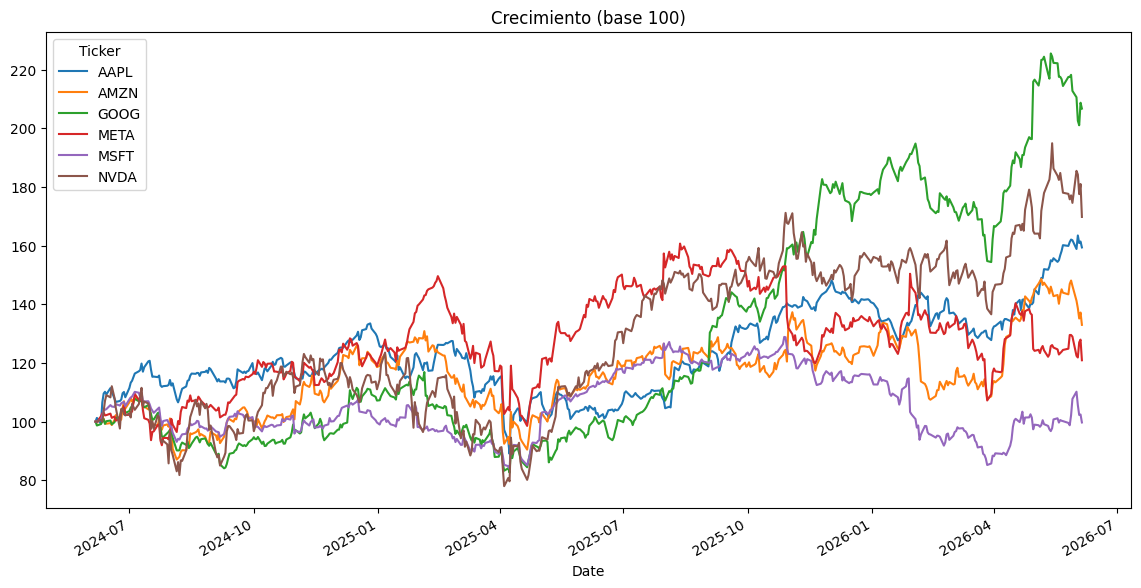

In [ ]:
# Graficamos los precios de cierre de los dos últimos años de cada empresa
(prices / prices.iloc[0] * 100).plot(figsize=(14, 7), title="Crecimiento (base 100)") 
# Lo ponemos en base 100 para que desde el día 1 que comparamos, cada uno muestre cuanto crecio en porcentaje y no en precio
plt.show()

In [9]:
# A primer ojo vemos que los picos de todas sin variables y lo que realmente importa no es cuántos picos hubieron, si no la distancia entre c/u
returns = prices.pct_change().dropna()
vol_anual = returns.std() * (252 ** 0.5) # 252 porque son los días al año que trabaja el mercado
print(vol_anual.sort_values(ascending=False))

Ticker
NVDA    0.481721
META    0.363688
AMZN    0.324888
GOOG    0.301910
AAPL    0.282990
MSFT    0.254296
dtype: float64


Al hacer un primer análisis de volatilidad notamos que aunque hay muchos picos en todas de las gráficas, lo que realmente importa es que tanta distancia hay entre cada uno de esos picos. El número que nos da esa variable es "vol_anual" que nos devuelve la votilidad anual de cada ticker que elegimos, siendo NVDA el más riesgoso y MSFT el menos riesgoso ya que sus picos se mantuvieron en un rango similar, pero en NVDA se dispararon en ciertos momentos.

Si nos damos cuenta en donde termina cada gráfica a día 05/06/2026, vemos que GOOGLE terminó en primer lugar, y aunque NVIDIA tuvo mucho riesgo, veamos si valió la pena semejante riesgo de 48% o GOOGLE ganó más con menos sustos.

In [11]:
# Ahora veamos como se comporta el Sharpe Ratio: Retorno por cada unidad de riesgo. Es la métrica que separa el "ganó mucho" a la de "ganó bien"
ret_anual = returns.mean() * 252
print(ret_anual.sort_values(ascending=False))

# Calculemos el Sharpe = (retorno-rf)/volatilidad donde rf es la tasa libre de riesgo
rf = 0.04
sharpe = (ret_anual-rf) / vol_anual
print(sharpe.sort_values(ascending=False))

Ticker
GOOG    0.411559
NVDA    0.382983
AAPL    0.274702
AMZN    0.196311
META    0.161395
MSFT    0.030770
dtype: float64
Ticker
GOOG    1.230695
AAPL    0.829365
NVDA    0.711995
AMZN    0.481122
META    0.333789
MSFT   -0.036298
dtype: float64
